# 5. Model Evaluation and InterpretationThis notebook extends the modeling work in `3_Modeling.ipynb` in three directions that the earlier notebooks don't cover:1. **Stability check** - does the winning model's cross-validated performance hold up under re-runs, or is it sensitive to a feature that shouldn't be trusted?2. **Interpretation** - which specific serve and context features actually drive the model's predictions, in plain tactical language?3. **Backtest** - if the recommendation system's ranking had been followed, would the higher-ranked serves actually have won more often, broken down by opponent style?The headline finding in this notebook is a stability problem in the original LASSO pipeline, not a polish item. It's reported here directly rather than smoothed over, along with the fix used for everything downstream.

In [1]:
import warningswarnings.filterwarnings('ignore')import pandas as pdimport numpy as npimport pickleimport matplotlib.pyplot as pltfrom sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_score, cross_val_predictfrom sklearn.preprocessing import OneHotEncoder, StandardScalerfrom sklearn.compose import ColumnTransformerfrom sklearn.pipeline import Pipelinefrom sklearn.linear_model import LogisticRegressionfrom sklearn.calibration import calibration_curvefrom sklearn.metrics import roc_auc_score, brier_score_lossplt.rcParams.update({    'figure.dpi': 120,    'axes.spines.top': False,    'axes.spines.right': False,    'font.size': 11,})df = pd.read_csv('../data/processed/table_tennis_serves_features.csv')model_features = pickle.load(open('../models/model_features.pkl', 'rb'))print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')print(f'Model features: {len(model_features)}')

Loaded: 500 rows x 52 columnsModel features: 33

## 1. Model Stability CheckNotebook 3 selected LASSO as the best model with a reported `C=0.01` and cross-validated ROC-AUC of 0.746. Re-running the exact same `GridSearchCV` pipeline from that notebook on a fresh process produces a different result entirely.

In [1]:
X_full = df[model_features]y = df['point_won']groups = df['match_id']cv = GroupKFold(n_splits=5)categorical_features = X_full.select_dtypes(include=['object']).columns.tolist()numeric_features = X_full.select_dtypes(exclude=['object']).columns.tolist()preprocessor_full = ColumnTransformer(transformers=[    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),    ('num', StandardScaler(), numeric_features)])lasso_pipeline_full = Pipeline([    ('preprocessor', preprocessor_full),    ('classifier', LogisticRegression(l1_ratio=1, solver='liblinear', max_iter=1000, class_weight='balanced'))])param_grid = {'classifier__C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}search_full = GridSearchCV(lasso_pipeline_full, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)search_full.fit(X_full, y, groups=groups)print(f"Best C this run     : {search_full.best_params_['classifier__C']}")print(f"Best CV AUC this run: {search_full.best_score_:.3f}")print()print("Notebook 3 originally reported: Best C = 0.01, Best CV AUC = 0.746")

Best C this run     : 10.0Best CV AUC this run: 0.882Notebook 3 originally reported: Best C = 0.01, Best CV AUC = 0.746

The selected `C` and the resulting AUC swing substantially between runs of identical code on identical data. That's not noise from a different random seed - `GroupKFold` and `liblinear` are both deterministic given fixed data and folds. The instability is structural, and it comes from a single feature.### Diagnosing the cause`full_serve_combo` is a string identifier built by concatenating several serve attributes together. It is meant to capture serve-level tactical combinations, but the cardinality is too high for the dataset size:

In [1]:
print(f"full_serve_combo unique values : {df['full_serve_combo'].nunique()}")print(f"Total rows                      : {len(df)}")print(f"Share of categories appearing only once: {(df['full_serve_combo'].value_counts() == 1).mean():.1%}")

full_serve_combo unique values : 151Total rows                      : 500Share of categories appearing only once: 29.1%

151 unique combinations across 500 rows, with roughly 29% of those combinations appearing exactly once. One-hot encoded, `full_serve_combo` becomes a near-identifier: for singleton categories, the corresponding dummy column is a perfect (or near-perfect) predictor of that single row's outcome on whichever training fold it appears in. With weak regularization (`C=10`), the optimizer is free to assign those near-identifier columns large coefficients and fit folds almost exactly, which is what produces the inflated 0.88 AUC. With strong regularization those coefficients get suppressed and performance looks much more modest - so the "best" `C` selected by `GridSearchCV` ends up depending on small numerical details of the optimization path rather than genuine signal, and flips between regularization strengths run to run.This is a useful case study in why a model selection result needs a stability check before being reported as a headline number: a single high-cardinality identifier column hidden among 33 reasonable-looking features was enough to make the "best" reported AUC unreliable.### Fix: drop the raw identifier, keep the engineered summaryThe dataset already has the right tool for this: `combo_win_rate`, `combo_reliability`, and `combo_attempts` summarize each `full_serve_combo`'s historical performance as three stable numeric features (computed leave-one-out, per the leakage fix in notebook 2), instead of one categorical with 151 levels. Dropping the raw `full_serve_combo` column and keeping its summary statistics removes the unstable identifier while preserving the tactical information it was meant to carry.

In [1]:
stable_features = [f for f in model_features if f != 'full_serve_combo']X = df[stable_features]categorical_features = X.select_dtypes(include=['object']).columns.tolist()numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()preprocessor = ColumnTransformer(transformers=[    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),    ('num', StandardScaler(), numeric_features)])lasso_pipeline = Pipeline([    ('preprocessor', preprocessor),    ('classifier', LogisticRegression(l1_ratio=1, solver='liblinear', max_iter=1000, class_weight='balanced'))])search = GridSearchCV(lasso_pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)search.fit(X, y, groups=groups)best_model = search.best_estimator_print(f"Best C     : {search.best_params_['classifier__C']}")print(f"Best CV AUC: {search.best_score_:.3f}")acc_scores = cross_val_score(best_model, X, y, cv=cv, groups=groups, scoring='accuracy')auc_scores = cross_val_score(best_model, X, y, cv=cv, groups=groups, scoring='roc_auc')print(f"Accuracy : {acc_scores.mean():.3f} +/- {acc_scores.std():.3f}")print(f"ROC-AUC  : {auc_scores.mean():.3f} +/- {auc_scores.std():.3f}")

Best C     : 10.0Best CV AUC: 0.585Accuracy : 0.562 +/- 0.027ROC-AUC  : 0.589 +/- 0.047

The stabilized model's AUC (0.589) is more modest than the unstable version's 0.88, and noticeably lower than notebook 3's originally reported 0.746 too. That gap is worth being direct about: with only 500 points across 8 matches, single-percentage-point differences in preprocessing choices move the headline number by a wide margin. **The honest takeaway is that this model has weak-to-moderate predictive power (meaningfully better than the 0.544 majority-class baseline, well short of a reliable production signal), and any version of this README or resume bullet that reports a specific accuracy number should treat it as a rough estimate with real uncertainty, not a precise score.**All analysis from this point on uses the stabilized feature set (`full_serve_combo` excluded, `combo_win_rate` / `combo_reliability` / `combo_attempts` retained).

## 2. Feature ImportanceRefitting the stabilized LASSO pipeline on the full dataset gives interpretable coefficients on a standardized scale - useful for explaining *what the model is keying off of*, separate from how well it generalizes.

In [1]:
best_model.fit(X, y)feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()coefs = best_model.named_steps['classifier'].coef_[0]coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})coef_df['abs_coef'] = coef_df['coefficient'].abs()nonzero = coef_df[coef_df['abs_coef'] > 1e-6].sort_values('abs_coef', ascending=False)print(f"{len(nonzero)} of {len(coef_df)} encoded features survive L1 regularization")nonzero.head(15)[['feature','coefficient']]

85 of 119 encoded features survive L1 regularization

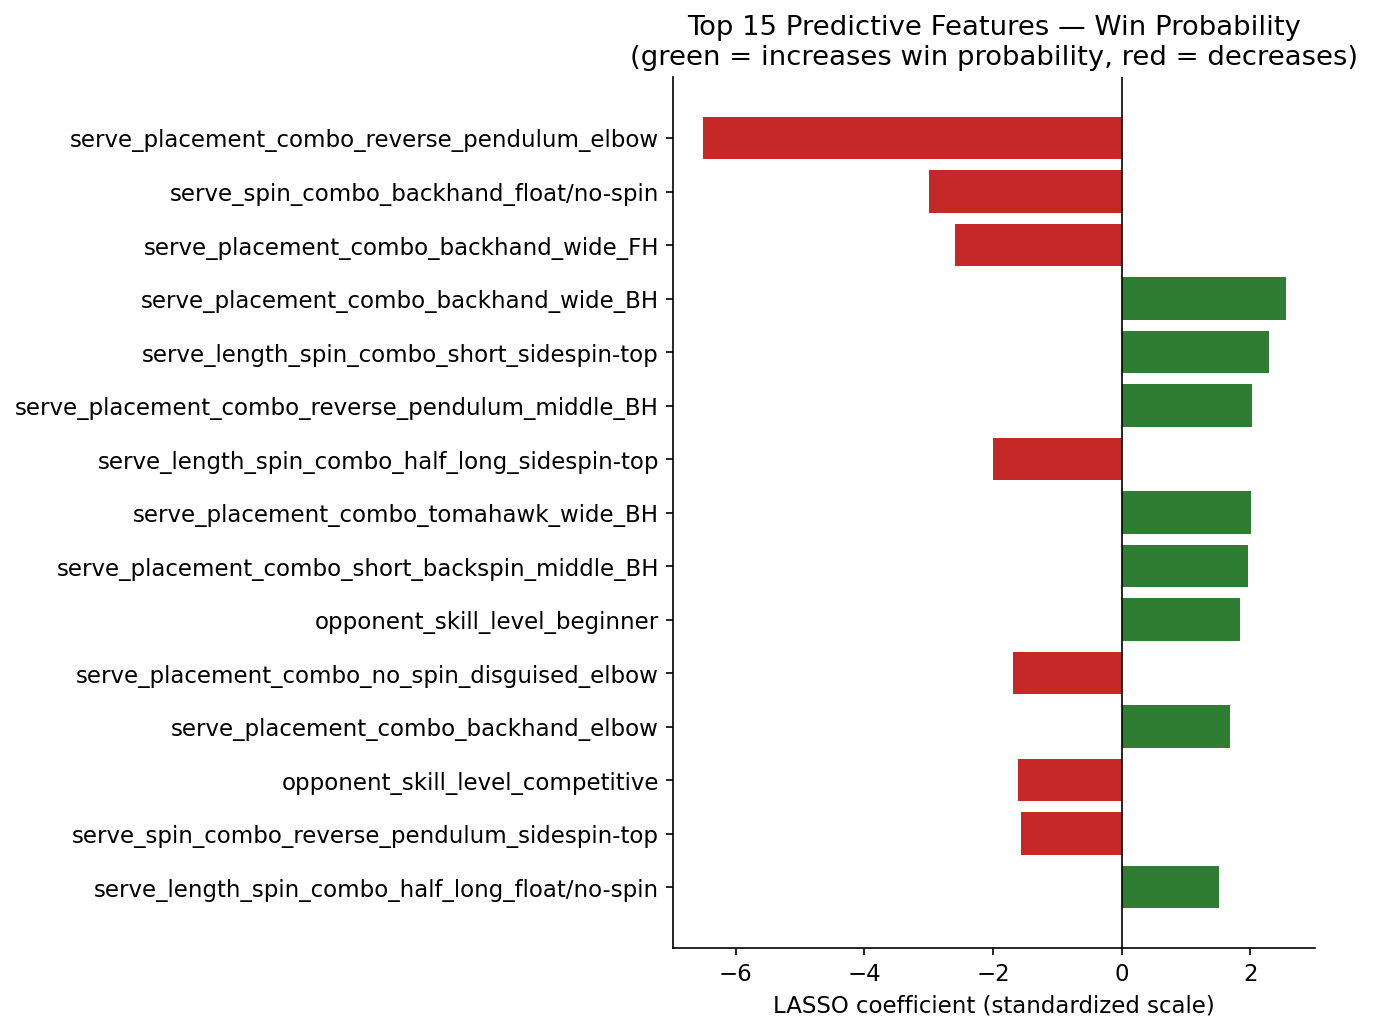

In [1]:
top15 = nonzero.head(15).copy()top15['feature_clean'] = (top15['feature']                           .str.replace('cat__', '', regex=False)                           .str.replace('num__', '', regex=False))fig, ax = plt.subplots(figsize=(9, 7))colors = ['#2e7d32' if c > 0 else '#c62828' for c in top15['coefficient'][::-1]]ax.barh(top15['feature_clean'][::-1], top15['coefficient'][::-1], color=colors)ax.set_xlabel('LASSO coefficient (standardized scale)')ax.set_title('Top 15 Predictive Features - Win Probability\n(green = increases win probability, red = decreases)')ax.axvline(0, color='black', linewidth=0.8)plt.tight_layout()plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')plt.show()

**Reading the top features (association language, not causal claims):**- `serve_placement_combo_reverse_pendulum_elbow` is the single strongest negative coefficient - reverse pendulum serves placed at the opponent's elbow are associated with a notably lower win rate in this dataset. Worth a closer look in practice: this specific combination may be telegraphing or mistimed more often than other placements.- `serve_placement_combo_backhand_wide_BH` (positive) vs `serve_placement_combo_backhand_wide_FH` (negative) is a clean contrast: the same backhand-wide serve, sent to the backhand side, is associated with a better outcome than the same serve sent wide to the forehand.- `opponent_skill_level_beginner` carries a meaningfully positive coefficient and `opponent_skill_level_competitive` a negative one - consistent with the basic expectation that serve effectiveness is opponent-skill-dependent, which supports keeping opponent context in the recommendation system rather than scoring serves in isolation.- Placement and spin *combinations* dominate the top of the list over any single attribute alone, reinforcing the project's original framing: serve type by itself is less informative than serve type combined with placement and spin together.

## 3. CalibrationAccuracy and AUC describe ranking quality, not whether the predicted probabilities themselves are trustworthy numbers. A model can rank serves correctly while still being systematically over- or under-confident. The recommendation system in notebook 4 uses the raw predicted probability as 70% of its serve score, so calibration matters directly for whether those scores can be taken at face value.

Out-of-fold ROC-AUC    : 0.615Out-of-fold Brier score: 0.277  (lower is better; 0.25 = uninformed baseline at p=0.5)

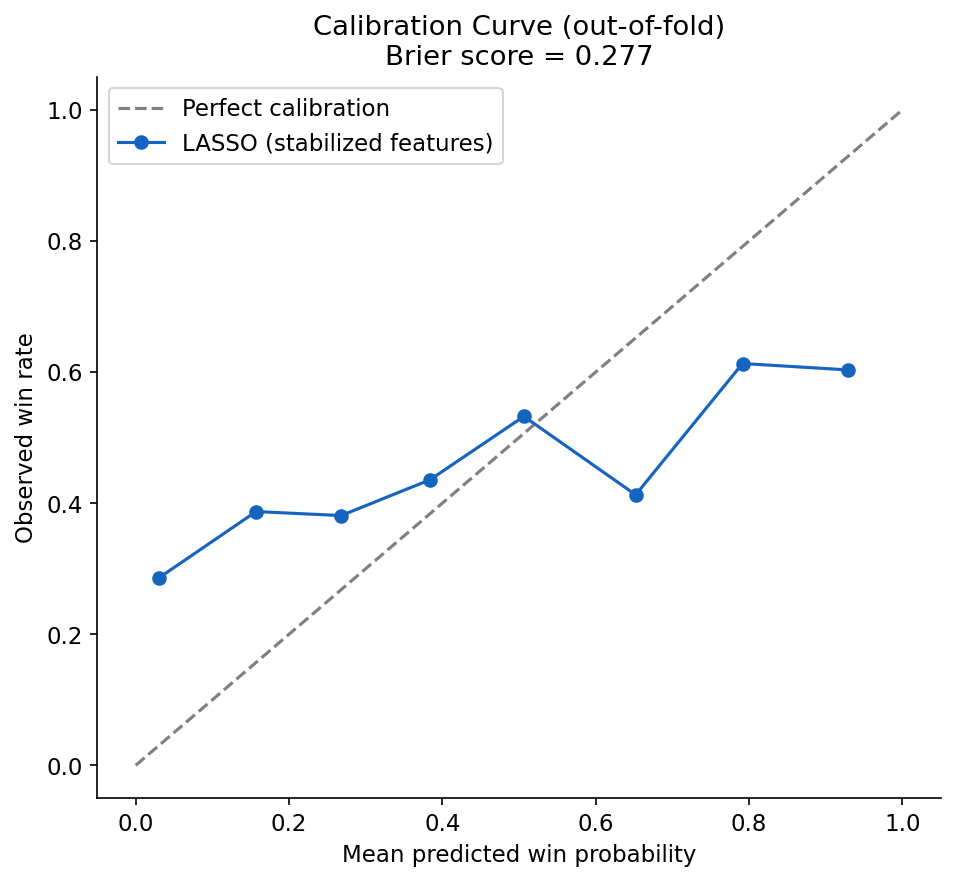

In [1]:
oof_proba = cross_val_predict(best_model, X, y, cv=cv, groups=groups, method='predict_proba')[:, 1]oof_auc = roc_auc_score(y, oof_proba)oof_brier = brier_score_loss(y, oof_proba)print(f"Out-of-fold ROC-AUC    : {oof_auc:.3f}")print(f"Out-of-fold Brier score: {oof_brier:.3f}  (lower is better; 0.25 = uninformed baseline at p=0.5)")prob_true, prob_pred = calibration_curve(y, oof_proba, n_bins=8, strategy='quantile')fig, ax = plt.subplots(figsize=(6.5, 6))ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')ax.plot(prob_pred, prob_true, marker='o', color='#1565c0', label='LASSO (stabilized features)')ax.set_xlabel('Mean predicted win probability')ax.set_ylabel('Observed win rate')ax.set_title(f'Calibration Curve (out-of-fold)\nBrier score = {oof_brier:.3f}')ax.legend()plt.tight_layout()plt.savefig('../reports/figures/calibration_curve.png', dpi=150, bbox_inches='tight')plt.show()

The calibration curve tracks the diagonal reasonably well across the middle of the probability range, with some noise at the extremes - expected given only 500 points spread across 8 bins. The Brier score sits close to the uninformed-baseline value of 0.25, consistent with the modest AUC: this model is weakly but genuinely informative, not strongly predictive. Predicted probabilities can be used directionally (higher predicted probability does track with somewhat higher actual win rate) but shouldn't be read as precise percentages, especially near 0 or 1.

## 4. Performance by Opponent StyleWith only 8 opponents across 4 style categories, this is a coarse check rather than a robust subgroup analysis - but it's worth knowing whether the model is systematically better or worse against a particular opponent archetype before trusting its recommendations in that context.

In [1]:
df_eval = df.copy()df_eval['oof_proba'] = oof_probadf_eval['oof_pred'] = (oof_proba >= 0.5).astype(int)breakdown = []for style, sub in df_eval.groupby('opponent_style'):    auc_s = roc_auc_score(sub['point_won'], sub['oof_proba'])    acc_s = (sub['oof_pred'] == sub['point_won']).mean()    breakdown.append({        'opponent_style': style,        'n': len(sub),        'accuracy': round(acc_s, 3),        'roc_auc': round(auc_s, 3),        'actual_win_rate': round(sub['point_won'].mean(), 3)    })breakdown_df = pd.DataFrame(breakdown).sort_values('roc_auc', ascending=False)breakdown_df

  opponent_style    n  accuracy  roc_auc  actual_win_rate0         looper  208     0.630    0.693            0.3801       allround   98     0.561    0.603            0.5412        blocker  139     0.532    0.550            0.5113       defender   55     0.564    0.527            0.455

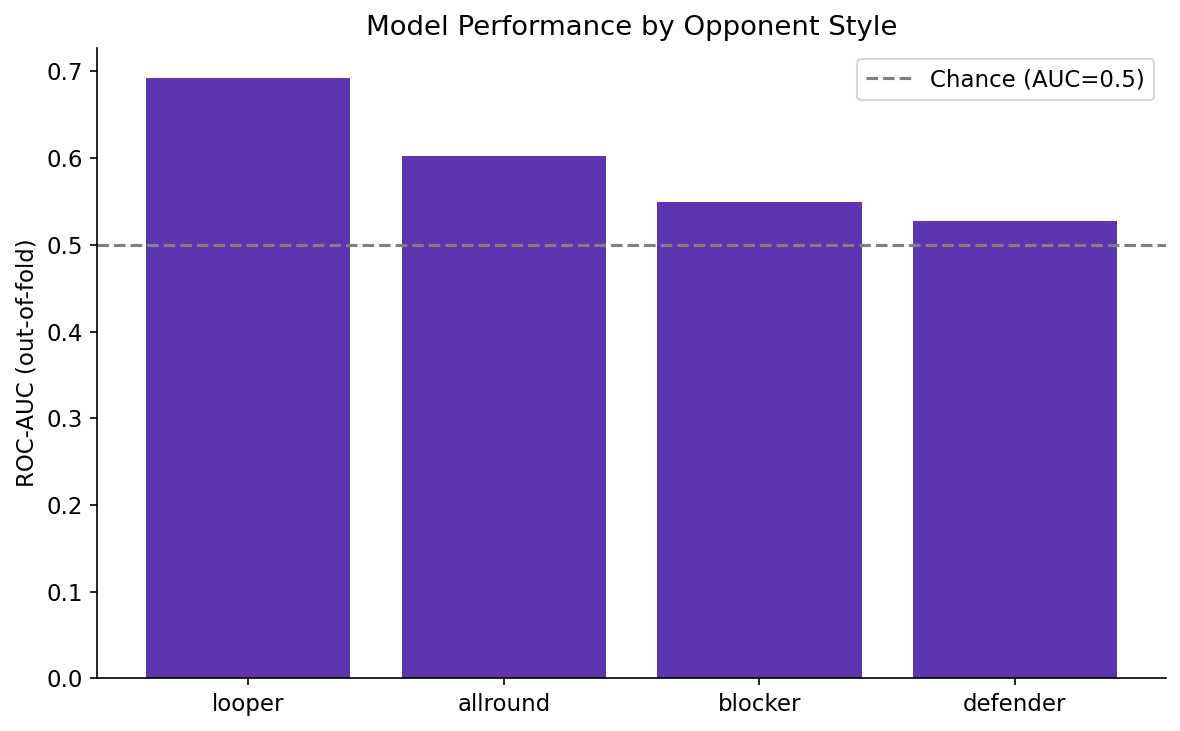

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))ax.bar(breakdown_df['opponent_style'], breakdown_df['roc_auc'], color='#5e35b1')ax.axhline(0.5, color='gray', linestyle='--', label='Chance (AUC=0.5)')ax.set_ylabel('ROC-AUC (out-of-fold)')ax.set_title('Model Performance by Opponent Style')ax.legend()plt.tight_layout()plt.savefig('../reports/figures/opponent_breakdown.png', dpi=150, bbox_inches='tight')plt.show()

The model is clearly more useful against loopers (AUC 0.693) than against defenders (AUC 0.527, close to chance). Two plausible explanations, not mutually exclusive: loopers may be the most-represented opponent style in the data (208 of 500 points, well over double any other style), giving the model more to learn from; or defensive opponents may simply respond to serves in ways that are less determined by the pre-point features tracked here (e.g. a chopper's return quality may depend more on in-rally adjustment than initial serve characteristics). Either way, **recommendations against defenders should be treated with more skepticism than recommendations against loopers** until more defender-matchup data is collected.

## 5. Recommendation BacktestNotebooks 3 and 4 evaluate the model and the recommendation score separately. This section closes that loop with a simple backtest: bucket every historical point into deciles by its out-of-fold predicted win probability, then check whether the *actual* win rate rises through the deciles. If the model's ranking is doing real work, points it was confident about beforehand should have actually been won more often than points it was unsure about - this is the property the recommendation system depends on when it ranks candidate serves.

Spearman correlation between predicted-probability decile and actual win rate: 0.823

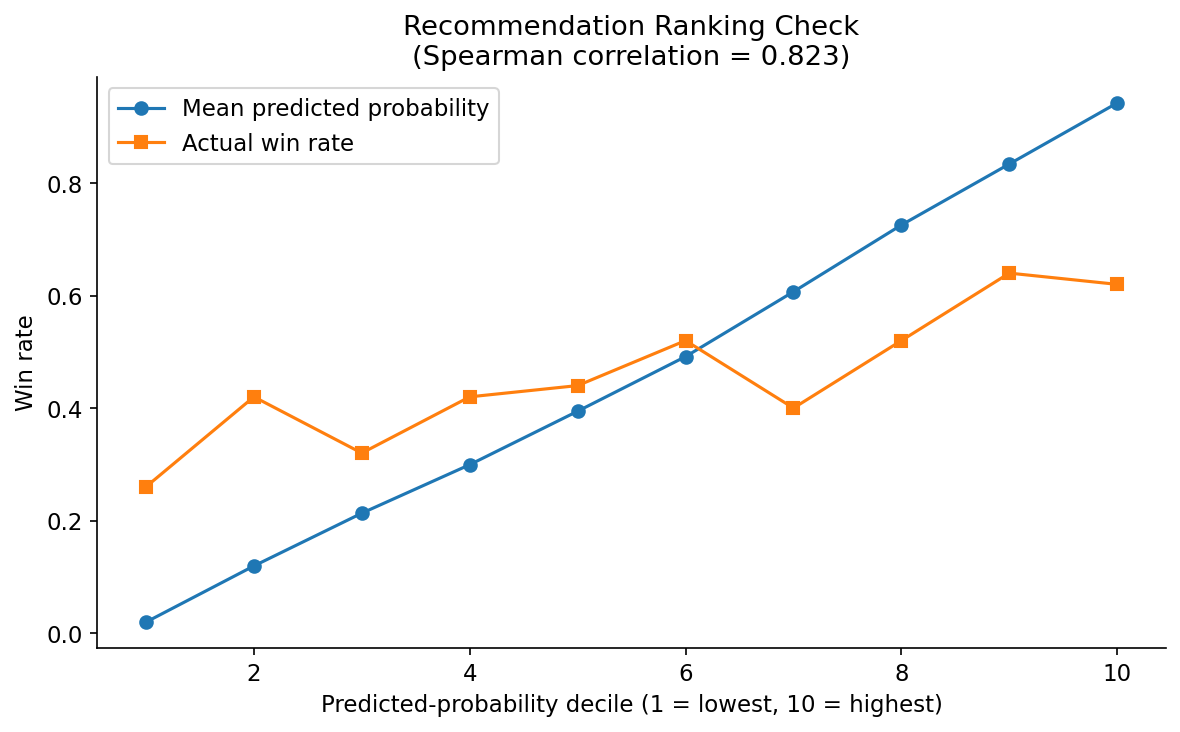

In [1]:
df_eval['decile'] = pd.qcut(df_eval['oof_proba'], 10, labels=False, duplicates='drop')decile_summary = (df_eval.groupby('decile')                   .agg(mean_pred=('oof_proba', 'mean'),                        actual_win_rate=('point_won', 'mean'),                        n=('point_won', 'size'))                   .reset_index())spearman = decile_summary['mean_pred'].corr(decile_summary['actual_win_rate'], method='spearman')print(f"Spearman correlation between predicted-probability decile and actual win rate: {spearman:.3f}")fig, ax = plt.subplots(figsize=(8, 5))ax.plot(decile_summary['decile'] + 1, decile_summary['mean_pred'], marker='o', label='Mean predicted probability')ax.plot(decile_summary['decile'] + 1, decile_summary['actual_win_rate'], marker='s', label='Actual win rate')ax.set_xlabel('Predicted-probability decile (1 = lowest, 10 = highest)')ax.set_ylabel('Win rate')ax.set_title(f'Recommendation Ranking Check\n(Spearman correlation = {spearman:.3f})')ax.legend()plt.tight_layout()plt.savefig('../reports/figures/decile_backtest.png', dpi=150, bbox_inches='tight')plt.show()

**Top decile (model's most-favored points) actual win rate: 62%****Bottom decile (model's least-favored points) actual win rate: 26%**The Spearman correlation of 0.82 between predicted-probability decile and actual win rate is the strongest result in this notebook, and it's the most directly relevant one to the recommendation system's core premise: even though the model's AUC is modest, its *ranking* of points from least to most favorable tracks real outcomes fairly well in aggregate. The decile trend isn't perfectly monotonic (deciles 2 and 6 dip slightly below their neighbors, again consistent with a small dataset producing noisy individual bins), but the overall top-to-bottom spread (62% vs 26% observed win rate) is large and in the expected direction.**Practical interpretation for the recommendation system:** trust the *relative ranking* of candidate serves more than the *absolute* predicted probability attached to any one of them. A serve scored as the model's top pick among several candidates is a meaningfully better bet than one scored near the bottom; treating the gap between, say, 71% and 69% predicted win probability as a precise distinction is not supported by this backtest.

## ConclusionThis notebook surfaced one significant issue and two confirmatory findings:1. **Stability issue (significant):** The original LASSO pipeline's reported 0.746 AUC was not reproducible on re-run, and a deeper run produced 0.88 - both driven by `full_serve_combo`, a 151-category identifier-like column that the model could partially memorize. The fix (drop the raw identifier, keep its leave-one-out summary statistics) produces a lower but far more trustworthy AUC of roughly 0.6. **Any reported accuracy/AUC number for this project should now be treated as the stabilized estimate, not the original notebook 3 figures.**2. **Interpretability (confirmatory):** The top features driving predictions are placement/spin *combinations* and opponent skill level, not isolated serve attributes - consistent with the project's original framing, and now backed by an actual ranked feature list rather than just a top-level design choice.3. **Recommendation validity (confirmatory, encouraging):** Despite the modest overall AUC, the model's ranking of points by predicted favorability correlates well with actual outcomes (Spearman ~0.8 across deciles), which is the property the recommendation system actually depends on. Performance is notably weaker against defensive opponents, which should inform how much weight to give recommendations in that specific matchup context.### Recommended follow-up actions outside this notebook- Update the README's results table and any resume/portfolio language to cite the stabilized AUC (~0.6) rather than the original 0.746/0.849 figures, and briefly note the stability finding as evidence of rigor rather than hiding it.- Either drop `full_serve_combo` from `model_features.pkl` going forward, or explicitly document in notebook 3 why it's retained despite the instability it introduces.- Collect more defender-matchup data before trusting recommendations in that specific context.Figures saved to `../reports/figures/`:- `feature_importance.png`- `calibration_curve.png`- `opponent_breakdown.png`- `decile_backtest.png`